In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adar5hsharma/population-analysis/population_data.csv


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np


# Load the dataset
df = pd.read_csv("/kaggle/input/datasets/adar5hsharma/population-analysis/population_data.csv")


In [23]:
# Calculate Population Density (Total Population / Area)
df["population_density"] = df["total_population"] / df["area"]

# Categorize density into Low, Medium, High based on quantiles
df["density_category"] = pd.qcut(df["population_density"], q=3, labels=["Low", "Medium", "High"])

# Calculate Male and Female Percentages
df["male_percentage"] = (df["male"] / df["total_population"]) * 100
df["female_percentage"] = (df["female"] / df["total_population"]) * 100

# Calculate Gender Gap (Male - Female)
df["gender_gap"] = df["male"] - df["female"]

# Calculate Sex Ratio (Male / Female * 100)
df["sex_ratio"] = (df["male"] / df["female"]) * 100

# Determine Gender Majority
df["gender_majority"] = np.where(df["male"] > df["female"], "Male Majority", "Female Majority")

# Summary Statistics
summary = df.describe()

# Average density by gender majority
density_by_gender = df.groupby("gender_majority")["population_density"].mean()

# Correlation between density and sex ratio
correlation = df[["population_density", "sex_ratio"]].corr().iloc[0, 1]



In [24]:


print("--- Summary Statistics ---")
print(summary)
print("\n--- Enhanced Density Categories ---")
print(df["density_category"].value_counts())
print("\n--- Gender Majority Distribution ---")
print(df["gender_majority"].value_counts())
print("\n--- Average Density by Gender Majority ---")
print(density_by_gender)
print(f"\nCorrelation between Density and Sex Ratio: {correlation:.4f}")





--- Summary Statistics ---
        ward_no    population       area         male       female  \
count  23.00000     23.000000  23.000000    23.000000    23.000000   
mean   12.00000   6041.347826   3.736522  3598.043478  3551.695652   
std     6.78233   2330.877822   3.890368  1475.891764  1542.610492   
min     1.00000   1489.000000   0.160000   914.000000   932.000000   
25%     6.50000   4373.000000   0.870000  2917.500000  2817.000000   
50%    12.00000   5871.000000   3.250000  3296.000000  3140.000000   
75%    17.50000   6801.500000   5.675000  4144.500000  4232.500000   
max    23.00000  12233.000000  16.350000  7282.000000  7485.000000   

       total_population  population_density  male_percentage  \
count         23.000000           23.000000        23.000000   
mean        7109.869565         6783.951567        50.934003   
std         3044.587676         7715.238559         2.203980   
min         1846.000000          470.918367        48.857913   
25%         5697.00000

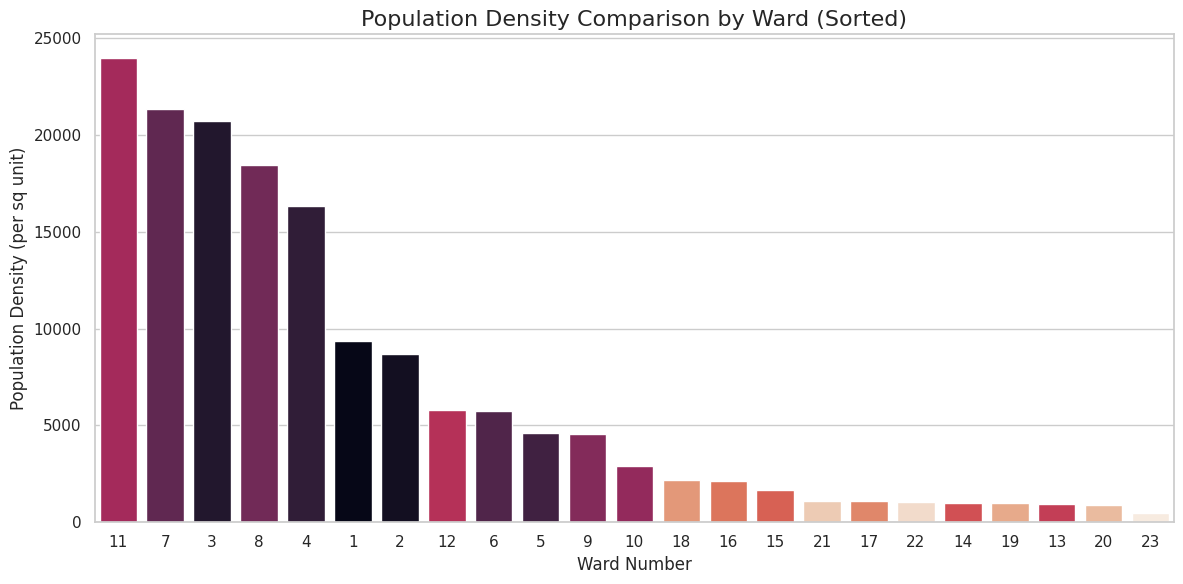

In [25]:
# Visualizations
sns.set_theme(style="whitegrid")

# 1. Population Density Comparison by Ward (Sorted)
plt.figure(figsize=(12, 6))
df_sorted_density = df.sort_values("population_density", ascending=False)
sns.barplot(
    x="ward_no", y="population_density",
    data=df_sorted_density,
    hue="ward_no",
    palette="rocket",
    order=df_sorted_density["ward_no"],
    legend=False
)
plt.title("Population Density Comparison by Ward (Sorted)", fontsize=16)
plt.xlabel("Ward Number", fontsize=12)
plt.ylabel("Population Density (per sq unit)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "improved_density_comparison.png"))
plt.show()
plt.close()



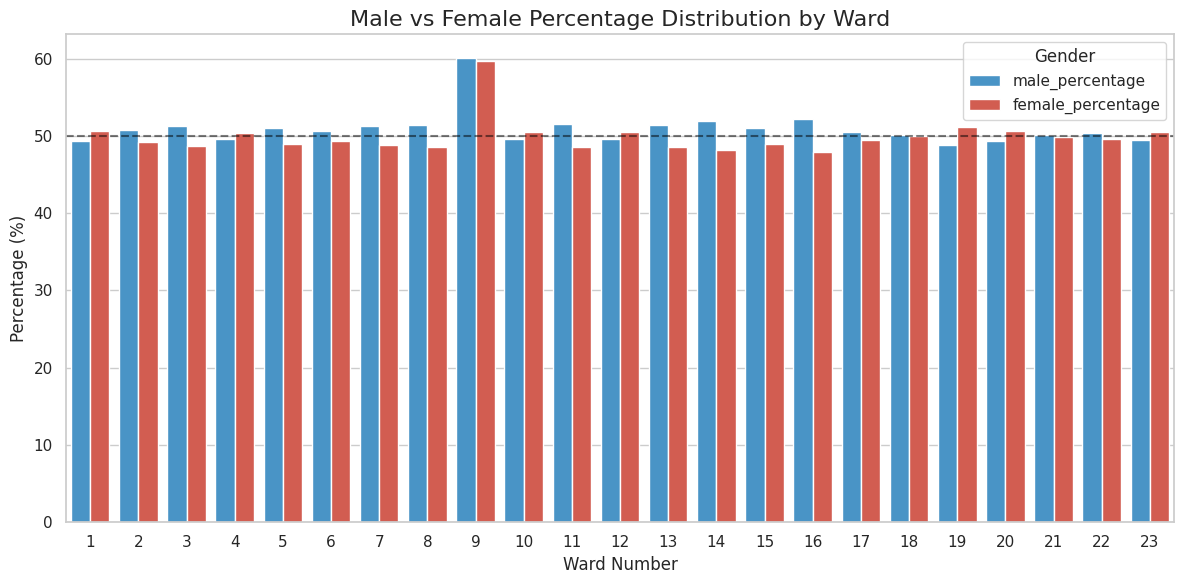

In [26]:
# 2. Male vs Female Percentage Distribution
plt.figure(figsize=(12, 6))
df_melted = df.melt(
    id_vars="ward_no",
    value_vars=["male_percentage", "female_percentage"],
    var_name="Gender",
    value_name="Percentage"
)
sns.barplot(x="ward_no", y="Percentage", hue="Gender", data=df_melted, palette=["#3498db", "#e74c3c"])
plt.axhline(50, color="black", linestyle="--", alpha=0.5)
plt.title("Male vs Female Percentage Distribution by Ward", fontsize=16)
plt.xlabel("Ward Number", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.legend(title="Gender")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "improved_gender_percentage.png"))
plt.show()
plt.close()



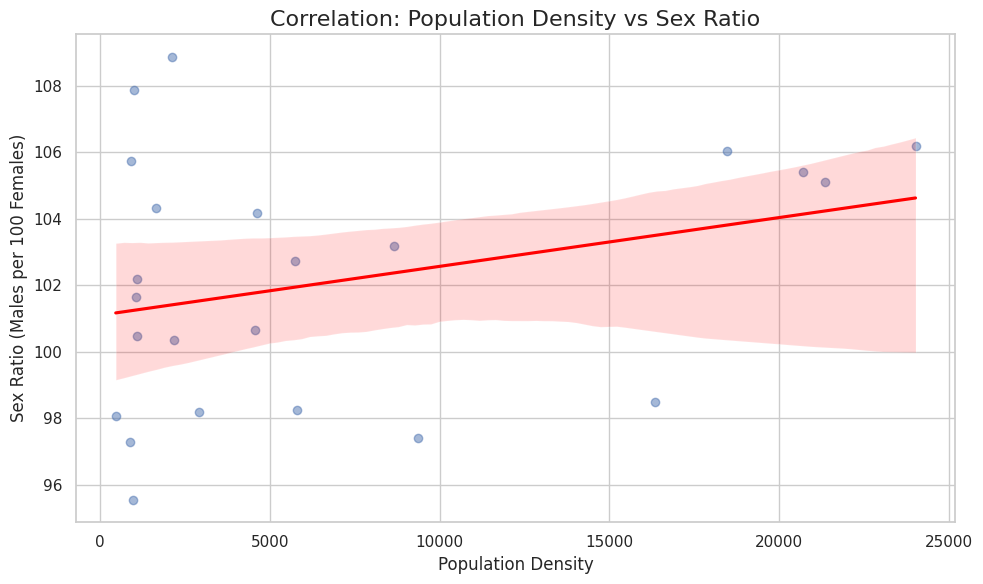

In [27]:
# 3. Sex Ratio vs Population Density
plt.figure(figsize=(10, 6))
sns.regplot(
    x="population_density", y="sex_ratio",
    data=df,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Correlation: Population Density vs Sex Ratio", fontsize=16)
plt.xlabel("Population Density", fontsize=12)
plt.ylabel("Sex Ratio (Males per 100 Females)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "density_vs_sex_ratio.png"))
plt.show()
plt.close()



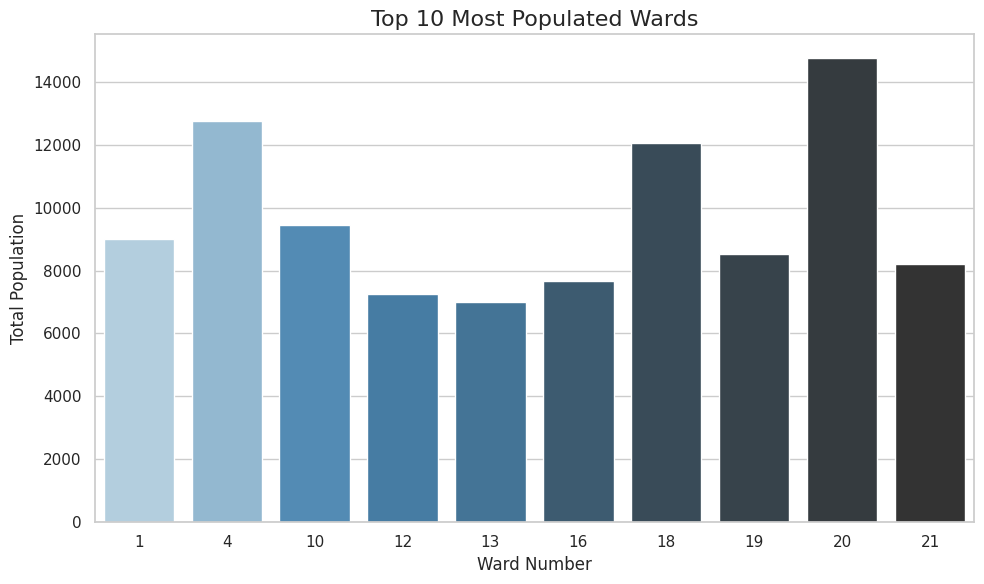

In [28]:
# 4. Top 10 Most Populated Wards
plt.figure(figsize=(10, 6))
top10 = df.nlargest(10, "total_population")
sns.barplot(
    x="ward_no", y="total_population",
    data=top10,
    hue="ward_no",
    palette="Blues_d",
    legend=False
)
plt.title("Top 10 Most Populated Wards", fontsize=16)
plt.xlabel("Ward Number", fontsize=12)
plt.ylabel("Total Population", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "top10_populated_wards.png"))
plt.show()
plt.close()



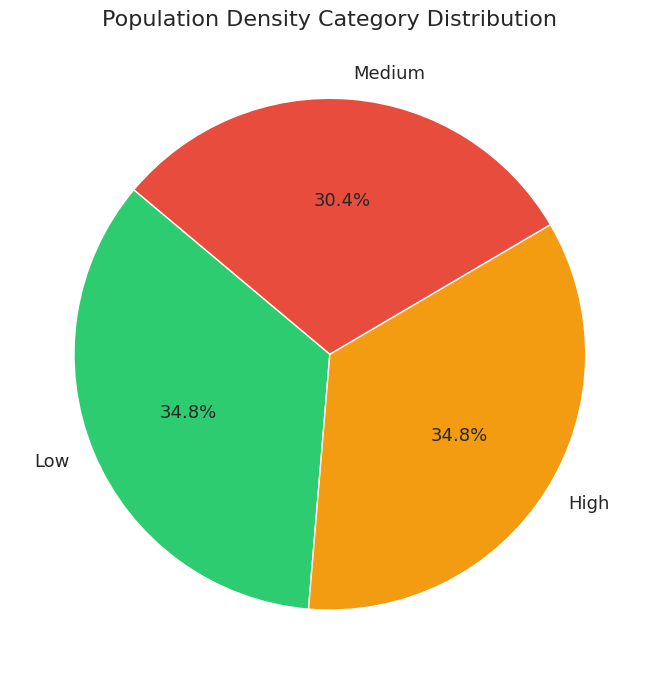

In [29]:


# 5. Density Category Distribution (Pie Chart)
plt.figure(figsize=(7, 7))
df["density_category"].value_counts().plot.pie(
    autopct="%1.1f%%",
    colors=["#2ecc71", "#f39c12", "#e74c3c"],
    startangle=140,
    textprops={"fontsize": 13}
)
plt.title("Population Density Category Distribution", fontsize=16)
plt.ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "density_category_pie.png"))
plt.show()
plt.close()